# Week 1: The Multi-Armed Bandit Problem and MDP Foundations

## Topics:

- Exploration vs. exploitation tradeoff
- Action-value methods (ε-greedy, UCB only)
- Markov Decision Processes
- Returns, value functions, Bellman equations
- Gymnasium API introduction
- NumPy for arrays and mathematical operations

## Learning Objectives:

- Understand the fundamental RL problem through the bandit framework
- Implement and compare basic exploration strategies
- Formalize sequential decision problems as MDPs
- Map theoretical RL concepts (states, actions, rewards, transitions) to Gymnasium API
- Write agents that interact with standard RL environments

## Reading: 

- Sutton & Barto Chapter 2 (Multi-armed Bandits)
- Sutton & Barto Chapter 3 (Finite MDPs)

# Lab Assignment - Part 1

Create a custom multi-armed bandit environment that follows the Gymnasium API structure (implement reset() and step() methods). The bandit should have 10 arms with Gaussian reward distributions. Implement ε-greedy and UCB algorithms as agents using NumPy for numerical computations. Run 2000 time steps across 1000 independent runs. Plot average reward and optimal action percentage over time for each algorithm with multiple parameter settings (try ε ∈ {0.01, 0.1, 0.2} and different UCB confidence levels).

## Design

This assignment is implemented as a modular multi-armed bandit framework split across five source files that follows a clean separation of concerns: 
- a Gymnasium-compatible MultiArmedBanditEnv that models 10 arms with configurable reward distributions (Gaussian distribution in this demonstration)
- an abstract BanditAgent base class with incremental mean updates. Two concrete agents implemented

    - EpsilonGreedyAgent
    - UCBAgent
- factory functions for convenient construction of environments and agents by name
- a simulation runner that executes 1,000 independent runs of 2,000 steps each while tracking per-step rewards, optimal action selection, and cumulative regret
- a plotting module that produces multi-panel comparison charts with smoothing.

The notebook itself stays high-level, using the factories to wire everything together, run the five agent configurations (ε ∈ {0.01, 0.1, 0.2} and UCB c ∈ {1.0, 2.0}), and visualize the results — keeping orchestration in the notebook while all algorithmic and infrastructure logic lives in the {repository root}/W1/part_01/src/ package.

### UML Diagram

<img src="./part_01/img/class_diagram.png">

## Implementation

### Link to Source Code

https://github.com/craig-rudman/MSDS684/tree/main/W1

In [13]:
!tree -I __pycache__ part_01

part_01
├── img
│   ├── bandit_comparison.png
│   └── class_diagram.png
└── src
    ├── agents.py
    ├── bandit_env.py
    ├── factories.py
    ├── plotting.py
    └── runner.py

3 directories, 7 files


In [7]:
from part_01.src.factories import make_bandit_env

# Create a 10-armed Gaussian bandit (true means re-sampled each run)
env = make_bandit_env(k=10, dist="gaussian", randomize=True, max_steps=2000)


In [ ]:
from part_01.src.factories import make_agent
from part_01.src.runner import run_simulation

# Set up agents with multiple parameter settings
agents = [
    make_agent("epsilon_greedy", k=10, epsilon=0.01),
    make_agent("epsilon_greedy", k=10, epsilon=0.1),
    make_agent("epsilon_greedy", k=10, epsilon=0.2),
    make_agent("ucb", k=10, c=1.0),
    make_agent("ucb", k=10, c=2.0),
]

# Run 1000 independent runs of 2000 steps each
results = []
for agent in agents:
    print(f"Running {agent.agent_name}...")
    result = run_simulation(env, agent, n_runs=1000, agent_name=agent.agent_name)
    s = result.summary()
    print(f"  Reward: {s['final_mean_reward']:.3f} | "
          f"Optimal: {s['final_optimal_pct']:.1f}% | "
          f"Regret: {s['final_cumulative_regret']:.1f}")
    results.append(result)

Running ε-greedy (ε=0.01)...
  Reward: 1.370 | Optimal: 69.6% | Regret: 494.0
Running ε-greedy (ε=0.1)...
  Reward: 1.468 | Optimal: 85.1% | Regret: 396.2
Running ε-greedy (ε=0.2)...
  Reward: 1.166 | Optimal: 75.9% | Regret: 650.6
Running UCB (c=1.0)...
  Reward: 1.536 | Optimal: 94.8% | Regret: 68.3
Running UCB (c=2.0)...
  Reward: 1.486 | Optimal: 91.2% | Regret: 185.6



Plot saved to bandit_comparison.png


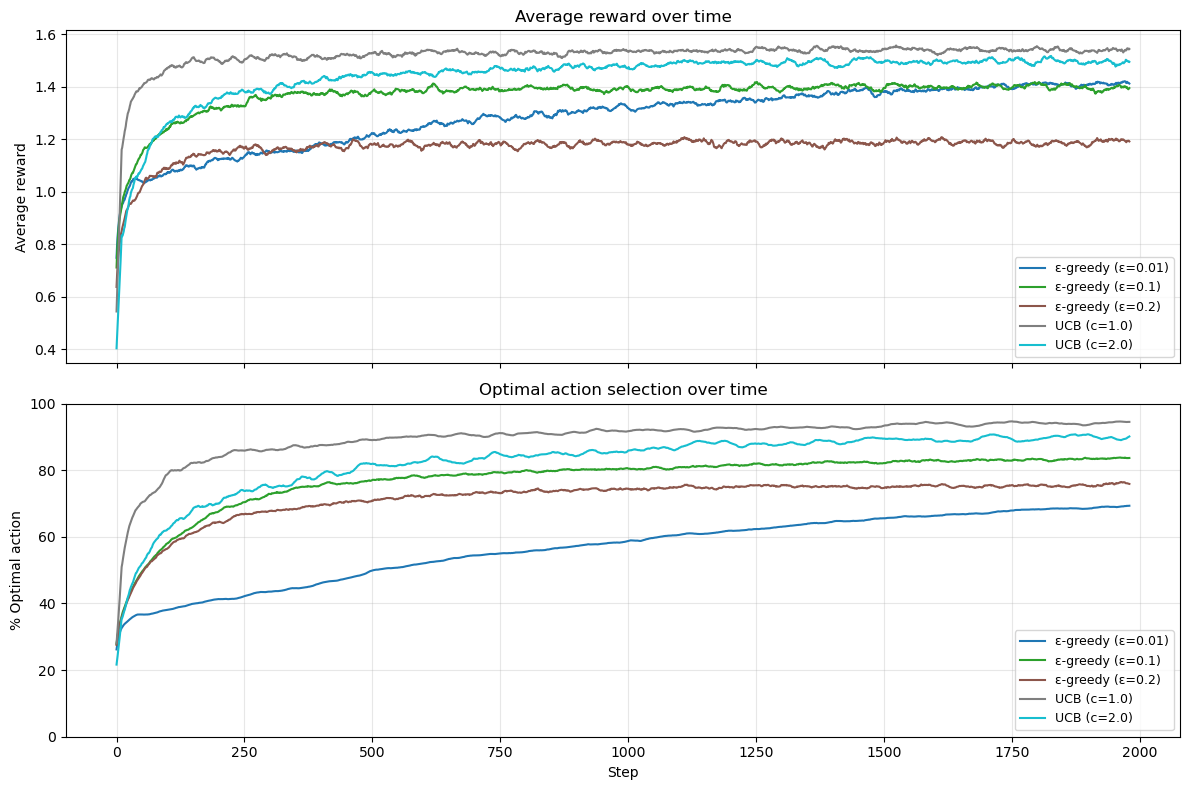

In [ ]:
from part_01.src.plotting import plot_comparison

# Plot average reward and optimal action percentage
plot_comparison(results, panels=["reward", "optimal_pct"], smoothing=20, save_path="img/bandit_comparison.png")
print("\nPlot saved to bandit_comparison.png")

## Summary

Using a custom Gymnasium-compatible environment, we ran 1,000 independent trials of 2,000 time steps each, comparing three ε-greedy parameterizations (ε ∈ {0.01, 0.1, 0.2}) against two UCB configurations (c ∈ {1.0, 2.0}). In this setting, UCB with c=1.0 provides the best overall performance, dominating all ε-greedy configurations in both convergence speed and asymptotic reward from the earliest steps onward. Among the ε-greedy agents, ε=0.1 achieves the best practical balance for this 2,000-step horizon — ε=0.01 is too conservative to gather sufficient information and is still climbing at the end of the run, while ε=0.2 identifies good arms quickly but permanently sacrifices too many pulls to random exploration, capping its performance well below ε=0.1. No ε-greedy parameterization matched UCB's combination of fast initial learning and high final performance, illustrating the advantage of directed exploration over uniform random exploration.

# Lab Assignment - Part 2

Explore Gymnasium’s standard environments (FrozenLake-v1, Taxi-v3). Write code to inspect their observation and action spaces (discrete vs. continuous, dimensions, bounds). Implement a random policy agent and measure its performance. Document how the MDP tuple (S, A, R, P, γ) maps to Gymnasium’s API. Your implementation should be modular with separate agent classes that interact with environments through the standard interface.

## Design

This assignment is implemented as a modular framework for evaluating agents in standard Gymnasium environments, split across four source files:
- an **environment inspector** (`env_inspector.py`) that introspects observation and action spaces, extracts transition tables, and formats summaries
- an abstract **Agent** base class with a concrete **RandomAgent** (`agents.py`) that selects actions uniformly at random
- an **episodic simulation runner** (`runner.py`) that collects per-episode returns, step counts, and success indicators across many episodes
- a **plotting module** (`plotting.py`) that produces return distributions and rolling success rate charts

The notebook orchestrates environment inspection, agent evaluation, and visualization for FrozenLake-v1 and Taxi-v3, while all logic lives in the `part_02/src/` package.

### Class Diagram

```mermaid
classDiagram
    direction LR

    class Agent {
        <<abstract>>
        +action_space : gym.Space
        +np_random : Generator
        +agent_name : str
        +__init__(action_space, seed)
        +select_action(observation)* int
        +update(observation, action, reward, next_observation, terminated, truncated)
        +reset()
    }

    class RandomAgent {
        +__init__(action_space, seed)
        +select_action(observation) int
    }

    class EpisodeResult {
        <<dataclass>>
        +agent_name : str
        +env_id : str
        -_returns : ndarray
        -_lengths : ndarray
        -_successes : ndarray
        +returns() ndarray
        +lengths() ndarray
        +successes() ndarray
        +summary() dict
    }

    class env_inspector {
        <<module>>
        +describe_space(space) dict
        +inspect_env(env) dict
        +get_transition_table(env) dict | None
        +format_inspection(info) str
    }

    class run_episodes {
        <<function>>
        +run_episodes(env, agent, n_episodes, agent_name, success_reward) EpisodeResult
    }

    class plot_episode_metrics {
        <<function>>
        +plot_episode_metrics(result, figsize, save_path) Figure
    }

    Agent <|-- RandomAgent : extends
    run_episodes ..> Agent : uses
    run_episodes ..> EpisodeResult : creates
    plot_episode_metrics ..> EpisodeResult : reads
    env_inspector ..> gym.Env : inspects
```

## MDP Tuple → Gymnasium API Mapping

| MDP Element | Symbol | Gymnasium API |
|---|---|---|
| **States** | S | `env.observation_space` defines the set; `obs` returned by `reset()` and `step()` is the current state |
| **Actions** | A | `env.action_space` defines the set; passed as argument to `step(action)` |
| **Rewards** | R(s, a, s') | `reward` scalar returned by `step()` |
| **Transition dynamics** | P(s', r \| s, a) | `env.unwrapped.P` dict (available for tabular envs like FrozenLake and Taxi); format: `{state: {action: [(prob, next_state, reward, terminated)]}}` |
| **Discount factor** | γ | Not part of the env API — this is an agent/algorithm parameter |
| **Terminal signal** | — | `terminated` and `truncated` booleans from `step()` define episode boundaries |

## Implementation

In [14]:
!tree -I __pycache__ part_02

part_02
├── img
└── src
    ├── agents.py
    ├── env_inspector.py
    ├── plotting.py
    └── runner.py

3 directories, 4 files


### 2.1 FrozenLake-v1

In [15]:
import gymnasium as gym
from part_02.src.env_inspector import inspect_env, format_inspection, get_transition_table

# Create FrozenLake with stochastic dynamics (is_slippery=True is the default)
fl_env = gym.make("FrozenLake-v1", is_slippery=True)

# Inspect observation and action spaces
fl_info = inspect_env(fl_env)
print(format_inspection(fl_info))

Environment: FrozenLake-v1

Observation Space (Discrete):
  States: 16 (indexed 0..15)
  Dimensions: 1

Action Space (Discrete):
  Actions: 4 (indexed 0..3)
  Dimensions: 1

Max episode steps: 100


In [16]:
# Examine transition dynamics for a sample state
# FrozenLake exposes P[state][action] = [(prob, next_state, reward, terminated)]
P = get_transition_table(fl_env)

# Show transitions from state 0 (top-left corner)
state = 0
action_names = ["Left", "Down", "Right", "Up"]
print(f"Transition table for state {state}:\n")
for action_idx, action_name in enumerate(action_names):
    transitions = P[state][action_idx]
    print(f"  Action {action_idx} ({action_name}):")
    for prob, next_state, reward, done in transitions:
        print(f"    P(s'={next_state}) = {prob:.4f}, R = {reward}, done = {done}")

Transition table for state 0:

  Action 0 (Left):
    P(s'=0) = 0.3333, R = 0, done = False
    P(s'=0) = 0.3333, R = 0, done = False
    P(s'=4) = 0.3333, R = 0, done = False
  Action 1 (Down):
    P(s'=0) = 0.3333, R = 0, done = False
    P(s'=4) = 0.3333, R = 0, done = False
    P(s'=1) = 0.3333, R = 0, done = False
  Action 2 (Right):
    P(s'=4) = 0.3333, R = 0, done = False
    P(s'=1) = 0.3333, R = 0, done = False
    P(s'=0) = 0.3333, R = 0, done = False
  Action 3 (Up):
    P(s'=1) = 0.3333, R = 0, done = False
    P(s'=0) = 0.3333, R = 0, done = False
    P(s'=0) = 0.3333, R = 0, done = False


In [17]:
from part_02.src.agents import RandomAgent
from part_02.src.runner import run_episodes

# Run 1000 episodes with a random agent
fl_agent = RandomAgent(fl_env.action_space)
fl_result = run_episodes(fl_env, fl_agent, n_episodes=1000)

# Print summary statistics
s = fl_result.summary()
print(f"FrozenLake-v1 — Random Agent ({s['n_episodes']} episodes)")
print(f"  Mean return:  {s['mean_return']:.4f} ± {s['std_return']:.4f}")
print(f"  Mean length:  {s['mean_length']:.1f} steps")
print(f"  Success rate: {s['success_rate']:.1f}%")

FrozenLake-v1 — Random Agent (1000 episodes)
  Mean return:  0.0210 ± 0.1434
  Mean length:  7.5 steps
  Success rate: 2.1%


Plot saved to part_02/img/frozenlake_random.png


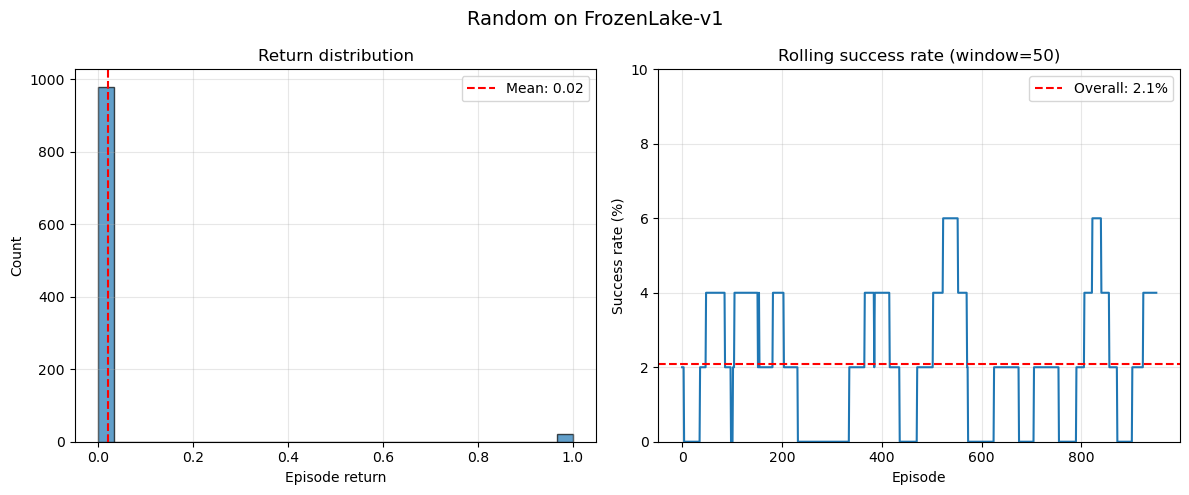

In [18]:
from part_02.src.plotting import plot_episode_metrics

plot_episode_metrics(fl_result, save_path="part_02/img/frozenlake_random.png")
print("Plot saved to part_02/img/frozenlake_random.png")

### 2.2 Taxi-v3

In [19]:
# Create Taxi environment
taxi_env = gym.make("Taxi-v3")

# Inspect observation and action spaces
taxi_info = inspect_env(taxi_env)
print(format_inspection(taxi_info))

Environment: Taxi-v3

Observation Space (Discrete):
  States: 500 (indexed 0..499)
  Dimensions: 1

Action Space (Discrete):
  Actions: 6 (indexed 0..5)
  Dimensions: 1

Max episode steps: 200


In [20]:
# Examine transition dynamics for a sample state
# Taxi state encodes (taxi_row, taxi_col, passenger_location, destination)
# State 328 = taxi at (3,2), passenger at index 2 (Yellow), destination index 0 (Red)
P_taxi = get_transition_table(taxi_env)

state = 328
action_names = ["South", "North", "East", "West", "Pickup", "Dropoff"]
print(f"Transition table for state {state}:\n")
for action_idx, action_name in enumerate(action_names):
    transitions = P_taxi[state][action_idx]
    print(f"  Action {action_idx} ({action_name}):")
    for prob, next_state, reward, done in transitions:
        print(f"    P(s'={next_state}) = {prob:.4f}, R = {reward}, done = {done}")

Transition table for state 328:

  Action 0 (South):
    P(s'=428) = 1.0000, R = -1, done = False
  Action 1 (North):
    P(s'=228) = 1.0000, R = -1, done = False
  Action 2 (East):
    P(s'=348) = 1.0000, R = -1, done = False
  Action 3 (West):
    P(s'=328) = 1.0000, R = -1, done = False
  Action 4 (Pickup):
    P(s'=328) = 1.0000, R = -10, done = False
  Action 5 (Dropoff):
    P(s'=328) = 1.0000, R = -10, done = False


In [21]:
# Run 1000 episodes with a random agent
taxi_agent = RandomAgent(taxi_env.action_space)
taxi_result = run_episodes(taxi_env, taxi_agent, n_episodes=1000, success_reward=19.0)

# Print summary statistics
s = taxi_result.summary()
print(f"Taxi-v3 — Random Agent ({s['n_episodes']} episodes)")
print(f"  Mean return:  {s['mean_return']:.2f} ± {s['std_return']:.2f}")
print(f"  Mean length:  {s['mean_length']:.1f} steps")
print(f"  Success rate: {s['success_rate']:.1f}%")

Taxi-v3 — Random Agent (1000 episodes)
  Mean return:  -768.77 ± 114.92
  Mean length:  195.5 steps
  Success rate: 5.4%


Plot saved to part_02/img/taxi_random.png


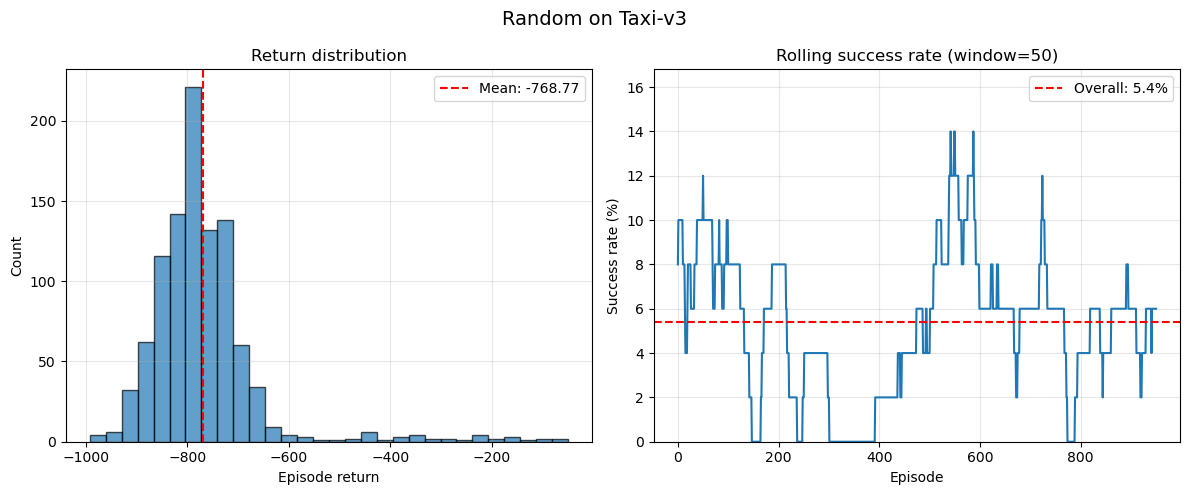

In [22]:
plot_episode_metrics(taxi_result, save_path="part_02/img/taxi_random.png")
print("Plot saved to part_02/img/taxi_random.png")